# <center> <img src="figs/logo_facens.png" alt="Logo Facens" width="110" align="left"/>  <br/> <center>Facens<br/>
</p>

<br/>
  
<font size="3"><center>Prof. Julio Cesar Mastrodomenico</center></font>




# Aprendizado de Máquinas
### 2023PGS2M2
----

## <center> $K$-Vizinhos mais próximos </center>

Implementação e utilização do algoritimo *K* - Vizinhos mais próximos

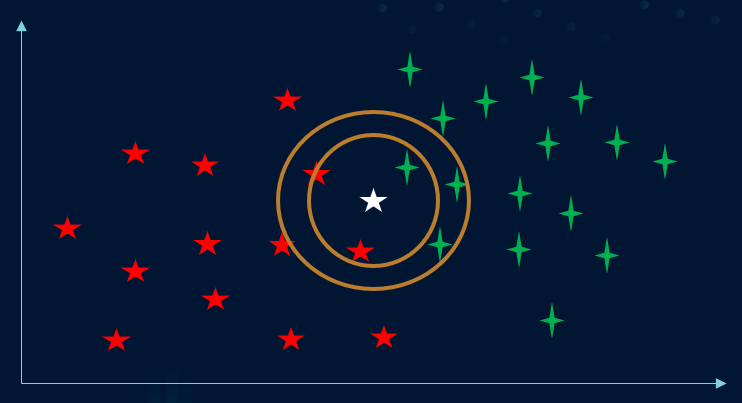

Banco de dados:
- Social_Network_Ads.csv
- Atrib_dataset.csv
- spam.csv
- titanic.csv


### Exercícios

## 1) Relembrando Naive Bayes e criando uma classe para o algoritimo, ao estilo Sklearn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, \
                            f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import datasets
import random

In [ ]:
# Importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('/content/Atrib_dataset.csv', sep=',', index_col=None)

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [ ]:
# Visualização das 6 primeiras linhas do nosso dataset
df_dataset.head(n=6)

,Atrib1,Atrib2,Atrib3,Atrib4,Atrib5,Classe
0,0,0,1,1,0,0
1,0,1,1,0,1,1
2,1,1,1,0,0,1
3,0,0,0,0,0,0
4,1,1,1,0,1,1
5,0,1,1,1,0,1


In [ ]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
Y = df_dataset.iloc[:, -1].values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

X: [[0 0 1 1 0]
 [0 1 1 0 1]
 [1 1 1 0 0]
 [0 0 0 0 0]
 [1 1 1 0 1]]
Y: [0 1 1 0 1]


In [ ]:
# Probabilidade das Classes
pPositivo = sum(Y==1)/len(Y)
pNegativo = sum(Y==0)/len(Y)

print('Probabilidade da classe ser 1 (Positivo): %1.2f%%' %(pPositivo*100))
print('Probabilidade da classe ser 0 (Negativo): %1.2f%%' %(pNegativo*100))

Probabilidade da classe ser 1 (Positivo): 54.00%
Probabilidade da classe ser 0 (Negativo): 46.00%


In [ ]:
def calcular_probabilidades(X, Y):
    """
    CALCULARPROBABILIDADES Computa a probabilidade de ocorrencia de cada
    atributo por rotulo possivel. A funcao retorna dois vetores de tamanho n
    (qtde de atributos), um para cada classe.

    CALCULARPROBABILIDADES(X, Y) calcula a probabilidade de ocorrencia de cada atributo em cada classe.
    Cada vetor de saida tem dimensao (n x 1), sendo n a quantidade de atributos por amostra.
    """

    #  inicializa os vetores de probabilidades
    pAtrPositivo = np.zeros(X.shape[1])
    pAtrNegativo = np.zeros(X.shape[1])

    for i in range(len(X[0])):
        pAtrPositivo[i] = sum(Y[np.where(X[:,i]==1)]==1)/sum(Y==1)
        pAtrNegativo[i] = sum(Y[np.where(X[:,i]==1)]==0)/sum(Y==0)

    ##########################################################################

    return pAtrPositivo, pAtrNegativo

pAtrPositivo, pAtrNegativo = calcular_probabilidades(X,Y)

print('A probabilidade esperada para P(Atributo1=1|Classe=1) = %.2f%%' %(pAtrPositivo[0]*100))

A probabilidade esperada para P(Atributo1=1|Classe=1) = 52.96%


In [ ]:
def classificacao(x,pPositivo,pNegativo,pAtrPositivo,pAtrNegativo):
    """
    Classifica se a entrada x pertence a classe 0 ou 1 usando
    as probabilidades extraidas da base de treinamento. Essa funcao
    estima a predicao de x atraves da maior probabilidade da amostra
    pertencer a classe 1 ou 0. Tambem retorna as probabilidades condicionais
    de positivo e negativo, respectivamente.

    """

    #  inicializa a classe e as probabilidades condicionais
    classe = 0;
    probPositivo= 0;
    probNegativo = 0;

    probPositivo = np.prod(abs((1-x)-pAtrPositivo))*pPositivo
    probNegativo = np.prod(abs((1-x)-pAtrNegativo))*pNegativo

    if probPositivo>probNegativo:
        classe = 1
    else:
        classe = 0

    ##########################################################################

    return classe, probPositivo, probNegativo

resultados = np.zeros( X.shape[0] )

for i in range(X.shape[0]):
    resultados[i], probPositivo, probNegativo = classificacao(X[i,:],pPositivo,pNegativo,pAtrPositivo,pAtrNegativo)

# calcular acuracia
acuracia = np.sum(resultados==Y)/len(Y)

print('Acuracia obtida pelo seu classificador foi = %.2f%%\n' %( acuracia*100 ) )

Acuracia obtida pelo seu classificador foi = 76.60%



In [ ]:
# Depois do modelo treinado, neste caso com as probabilidades calculadas, podemos
# predizer para um novo valor, seja ele x1_novo
x1_novo = np.array([0,1,0,1,1])

classe, probPositivo, probNegativo = classificacao(x1_novo, pPositivo, pNegativo, pAtrPositivo, pAtrNegativo)

if classe ==1:
    print('\n>>> Predicao = Positivo!')
else:
    print('\n>>> Predicao = Negativo!')

print('\n>>>>>> Prob. Positivo = %0.6f!' %(probPositivo))
print('\n>>>>>> Prob. Negativo = %0.6f!\n\n'  %(probNegativo))


>>> Predicao = Positivo!

>>>>>> Prob. Positivo = 0.019366!

>>>>>> Prob. Negativo = 0.009483!




In [ ]:
#Initializing the Naive Bayes Class
class NaiveBayes():

    #Class responsible for Naive Bayes
    def __init__(self):

        self.labels = 0

    def fit(self, X, Y):
        '''
        Função de Fitting, treinamento da classe
        Args: Entrada de features e as classes de saída
        Retorna: Nulo, armazena internamente as probabilidades
        '''

        # Inicia as variáveis que irão armazenar as labels e probabilidades
        self.labels = np.unique(Y)
        self.pClasse = np.zeros((len(np.unique(Y)),1))
        self.pAtrLabel = np.zeros((len(self.labels), X.shape[1]))

        # Calcula a probabilidade de cada classe
        for i in self.labels:
            self.pClasse[i] = sum(Y==i)/len(Y)

        # Calcula a probabilidade de cada atributo ocorrer em cada classe
        for i in self.labels:
            for j in range(len(X[0])):
                self.pAtrLabel[i][j] = sum(Y[np.where(X[:,j]==1)]==i)/sum(Y==i)

    def predict(self, x):
        '''
        Função de predict de novos dados.
        Args: Vetor a ser predito
        Retorna: Classe predita
        '''

        # Inicia a variável de saida
        probClasse = np.zeros((len(self.labels)))

        # Calcula a probabilidade de cada classe pertencer ao vetor a ser predito
        for i in range(len(self.labels)):
            probClasse[i] = np.prod(abs((1-x)-self.pAtrLabel[i]))*self.pClasse[i]

        # Retorna a classe máxima
        return np.argmax(probClasse)

    def predict_proba(self, x):
        '''
        Função de predict de novos dados.
        Args: Vetor a ser predito
        Retorna: Classe predita
        '''

        # Inicia a variável de saida
        probClasse = np.zeros((len(self.labels)))

        # Calcula a probabilidade de cada classe pertencer ao vetor a ser predito
        for i in range(len(self.labels)):
            probClasse[i] = np.prod(abs((1-x)-self.pAtrLabel[i]))*self.pClasse[i]

        # Retorna a classe máxima
        return probClasse

In [ ]:
naive_class = NaiveBayes()

In [ ]:
naive_class.fit(X,Y)

In [ ]:
naive_class.predict(x1_novo)

<ipython-input-11-ef31d254e57c>:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probClasse[i] = np.prod(abs((1-x)-self.pAtrLabel[i]))*self.pClasse[i]


1

In [ ]:
resultados = np.zeros( X.shape[0] )

for i in range(X.shape[0]):
    resultados[i] = naive_class.predict(X[i,:])

acuracia = np.sum(resultados==Y)/len(Y)

print('Acuracia obtida pelo seu classificador foi = %.2f%%\n' %( acuracia*100 ) )

Acuracia obtida pelo seu classificador foi = 76.60%



<ipython-input-11-ef31d254e57c>:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probClasse[i] = np.prod(abs((1-x)-self.pAtrLabel[i]))*self.pClasse[i]


In [ ]:
naive_class.predict_proba(x1_novo)

<ipython-input-11-ef31d254e57c>:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probClasse[i] = np.prod(abs((1-x)-self.pAtrLabel[i]))*self.pClasse[i]


array([0.00948265, 0.01936649])

## Criando a Classe do Naive Bayes Gaussiano

In [ ]:
import numpy as np

In [ ]:

class NaiveBayes:

    def __init__(self):
        self.means = None
        self.variances = None
        self.class_priors = None
        self.classes = None

    def fit(self, X, y):
        # Get number of samples (rows) and features (columns)
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initialize mean, variance, and class prior arrays
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))
        self.class_priors = np.zeros(n_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.means[idx, :] = X_c.mean(axis=0)
            self.variances[idx, :] = X_c.var(axis=0)
            self.class_priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_hat = [self.get_class_probability(x, self.means, self.variances, self.class_priors, len(self.classes)) for x in X]
        return np.array(y_hat)

    def get_class_probability(self, X, means, variances, priors, n_classes):
        # Posterior probabilities for each class
        posteriors = []

        for i in range(n_classes):
            mean = means[i]
            var = variances[i]
            prior = np.log(priors[i])

            # Calculate the log of the posterior probability for class i
            posterior = np.sum(np.log(self.gaussian_density(X, mean, var)))
            posterior = prior + posterior
            posteriors.append(posterior)

        return np.argmax(posteriors)

    def gaussian_density(self, x, mean, var):
        # Implementation of Gaussian density function
        const = 1 / np.sqrt(2 * np.pi * var)
        proba = np.exp(-0.5 * ((x - mean) ** 2) / var)

        return const * proba

In [ ]:
gaussian_class = NaiveBayes()

In [ ]:

!pip install scikit-learn # Install scikit-learn if you haven't already
from sklearn import datasets # Import the datasets module

data = datasets.load_iris()

In [ ]:
X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
gaussian_class.fit(X_train, y_train)

In [ ]:
pred = gaussian_class.predict(X_test)

In [ ]:
pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
f1_score(y_test, pred, average='macro')

1.0

## Criando nossa Classe de KNN

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k=3, d='euclidean'):
        """
        Inicializa o classificador KNN com o número de vizinhos.

        Parâmetros:
        k (int): Número de vizinhos a considerar. O padrão é 3.
        """
        self.k = k
        self.d = d

    def distance(self, x1):
        if self.d == 'euclidean':
            # Calculate Euclidean distance without the extra sum
            D = np.sqrt(np.sum((x1 - self.X)**2, axis=1))
        else:
            D = np.sum(np.abs(x1 - self.X), axis=1)
        return D

    def fit(self, X, y):
        """
        Ajusta o modelo KNN armazenando o conjunto de dados de treinamento.

        Parâmetros:
        X_train (array numpy): Características de treinamento.
        y_train (array numpy): Rótulos de treinamento.
        """
        self.X = X
        self.y = y

    def predict(self, X_pred):

        label = np.zeros(len(X_pred))

        for i in range(len(X_pred)):
            # Calcula a distância da amostra atual para todas as amostras no conjunto de treinamento
            distancias = self.distance(X_pred[i])
            # Obtém os índices dos k vizinhos mais próximos
            kviz = distancias.argsort()

            # Obtém as classes dos k vizinhos mais próximos
            idx_viz = kviz[:self.k]

            # Obtém os rótulos dos k vizinhos mais próximos
            y_viz = self.y[idx_viz]




            # Votação: Obtém o rótulo mais comum
            vote = np.bincount(y_viz)
            label[i] = np.argmax(vote)

        return label

In [ ]:
data = datasets.load_iris()

In [ ]:
X = data.data
y = data.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNN(k=3)

In [ ]:
knn.fit(X_train, y_train)

In [ ]:
pred = knn.predict(X_test)

In [ ]:
print(pred)

[1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.]


In [ ]:
f1_score(y_test, pred, average='macro')

1.0

In [ ]:
cmatrix = confusion_matrix(y_test, pred)
print(cmatrix)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Testando nossa classe com o Iris Dataset

In [ ]:
# Carregando o dataset
iris = datasets.load_iris(as_frame=True)

In [ ]:
# Visualizando os dados
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
iris.target

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


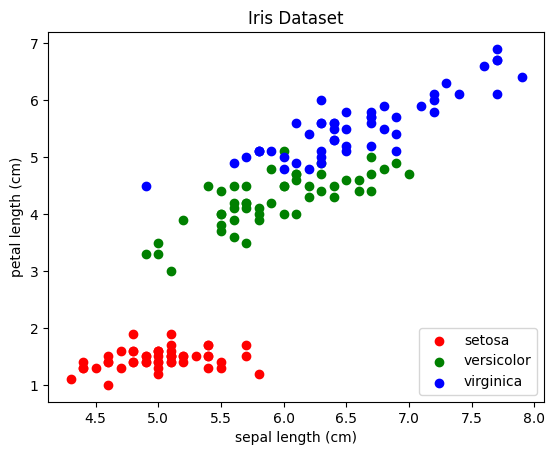

In [ ]:
# Plot de visualização dos dados
n_samples = len(iris.target)
for t in set(iris.target):
    x = [iris.data.iloc[i,0] for i in range(n_samples) if iris.target[i]==t]
    y = [iris.data.iloc[i,2] for i in range(n_samples) if iris.target[i]==t]
    plt.scatter(x,
                y,
                color=['red', 'green', 'blue'][t],
                label=iris.target_names[t])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title('Iris Dataset')
plt.legend(iris.target_names, loc='lower right')
plt.show()

In [ ]:
# Split do dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(iris.data.values, iris.target.values, test_size = 0.2, random_state = 0)

In [ ]:
# Instanciando nossa classe
knn = KNN(5, 'hamming')

In [ ]:
# Realizando o fit, neste caso passando os dados para o algoritmo iterar no predict
knn.fit(X_train, y_train)

In [ ]:
# Predizendo uma das linhas do teste
knn.predict([X_test[0]])

array([2.])

In [ ]:
X_test

array([[5.8, 2.8, 5.1, 2.4],
       [6. , 2.2, 4. , 1. ],
       [5.5, 4.2, 1.4, 0.2],
       [7.3, 2.9, 6.3, 1.8],
       [5. , 3.4, 1.5, 0.2],
       [6.3, 3.3, 6. , 2.5],
       [5. , 3.5, 1.3, 0.3],
       [6.7, 3.1, 4.7, 1.5],
       [6.8, 2.8, 4.8, 1.4],
       [6.1, 2.8, 4. , 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 3.2, 4.5, 1.5],
       [6.1, 2.8, 4.7, 1.2],
       [6.5, 2.8, 4.6, 1.5],
       [6.1, 2.9, 4.7, 1.4],
       [4.9, 3.6, 1.4, 0.1],
       [6. , 2.9, 4.5, 1.5],
       [5.5, 2.6, 4.4, 1.2],
       [4.8, 3. , 1.4, 0.3],
       [5.4, 3.9, 1.3, 0.4],
       [5.6, 2.8, 4.9, 2. ],
       [5.6, 3. , 4.5, 1.5],
       [4.8, 3.4, 1.9, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [6.2, 2.8, 4.8, 1.8],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.8, 1.9, 0.4],
       [6.2, 2.9, 4.3, 1.3],
       [5. , 2.3, 3.3, 1. ],
       [5. , 3.4, 1.6, 0.4]])

In [ ]:
# Calculando a acurácia do modelo nos dados de teste
accuracy_score(y_test, knn.predict(X_test))

1.0

## Testando agora com o KNN do Sklearn

In [ ]:
# Importando a lib
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Importar a classe e realizar o predict
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
pred = knn.predict(X_test)

In [ ]:
accuracy_score(y_test, pred)

0.9666666666666667

In [ ]:
acc = []

for i in [1, 3, 5, 7, 9]:
    knn_sk = KNeighborsClassifier(n_neighbors=i)
    knn_sk.fit(X_train, y_train)
    res = accuracy_score(y_test, knn_sk.predict(X_test))
    acc.append(res)
    print(f'Acurácia para k = {i}: {res}')

Acurácia para k = 1: 1.0
Acurácia para k = 3: 0.9666666666666667
Acurácia para k = 5: 0.9666666666666667
Acurácia para k = 7: 1.0
Acurácia para k = 9: 1.0


## Métricas:

- Matriz de Confusão

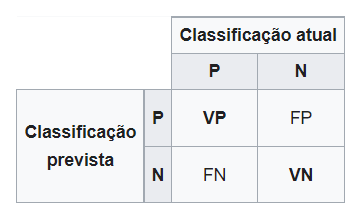


- Acurácia

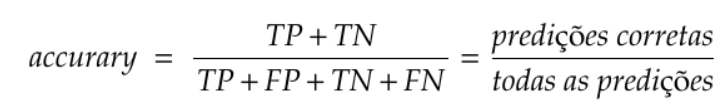


- Precisão

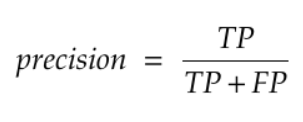


- recall

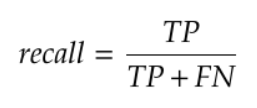


- Precisão / Recall

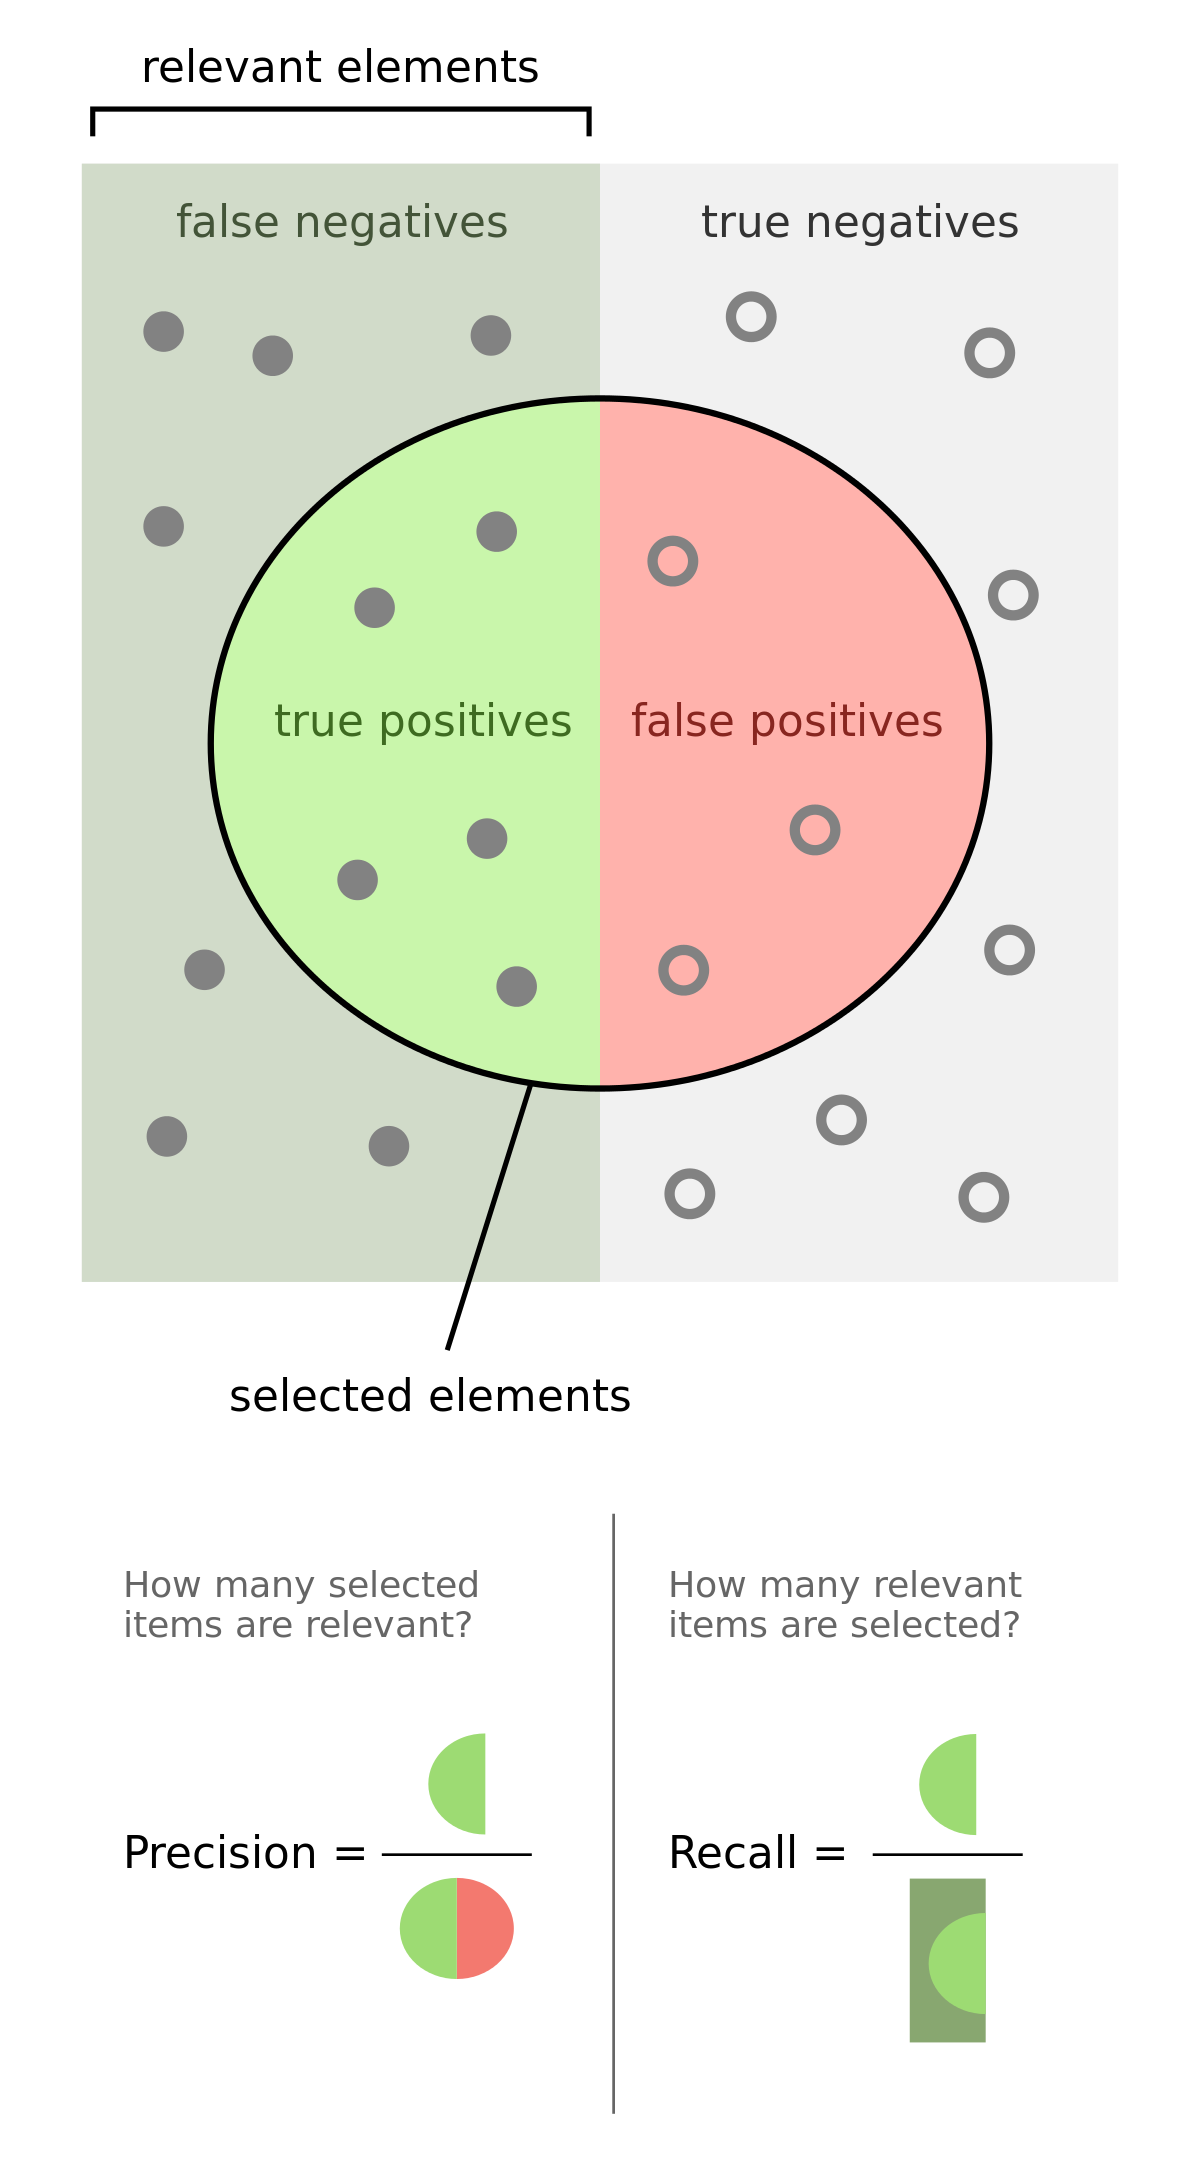


- F-Beta Score

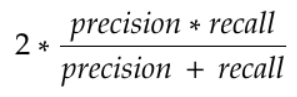



## Dataset Social_Ads com visualização do decision boundary do KNN

In [ ]:
# Importando o dataset e separando as variáveis
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
# Realizando o split do dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
# Vamos ver o que temos na variável X_train
X_train

array([[    44,  39000],
       [    32, 120000],
       [    38,  50000],
       [    32, 135000],
       [    52,  21000],
       [    53, 104000],
       [    39,  42000],
       [    38,  61000],
       [    36,  50000],
       [    36,  63000],
       [    35,  25000],
       [    35,  50000],
       [    42,  73000],
       [    47,  49000],
       [    59,  29000],
       [    49,  65000],
       [    45, 131000],
       [    31,  89000],
       [    46,  82000],
       [    47,  51000],
       [    26,  15000],
       [    60, 102000],
       [    38, 112000],
       [    40, 107000],
       [    42,  53000],
       [    35,  59000],
       [    48,  41000],
       [    48, 134000],
       [    38, 113000],
       [    29, 148000],
       [    26,  15000],
       [    60,  42000],
       [    24,  19000],
       [    42, 149000],
       [    46,  96000],
       [    28,  59000],
       [    39,  96000],
       [    28,  89000],
       [    41,  72000],
       [    45,  26000],


In [ ]:
# Vamos realizar uma normalização devido a grande diferença nas grandezas
sc = StandardScaler()
# Instanciamos ela
X_norm = sc.fit_transform(X_train)

# Para utilizar precisamos realizar um fit e um transform, para que realize o calculo de normalização
# e aplique no X_train
fit = sc.fit(X_train)
X_train = fit.transform(X_train)
# Posteriormente, só aplicamos no X_test
X_test

array([[    30,  87000],
       [    38,  50000],
       [    35,  75000],
       [    30,  79000],
       [    35,  50000],
       [    27,  20000],
       [    31,  15000],
       [    36, 144000],
       [    18,  68000],
       [    47,  43000],
       [    30,  49000],
       [    28,  55000],
       [    37,  55000],
       [    39,  77000],
       [    20,  86000],
       [    32, 117000],
       [    37,  77000],
       [    19,  85000],
       [    55, 130000],
       [    35,  22000],
       [    35,  47000],
       [    47, 144000],
       [    41,  51000],
       [    47, 105000],
       [    23,  28000],
       [    49, 141000],
       [    28,  87000],
       [    29,  80000],
       [    37,  62000],
       [    32,  86000],
       [    21,  88000],
       [    37,  79000],
       [    57,  60000],
       [    37,  53000],
       [    24,  58000],
       [    18,  52000],
       [    22,  81000],
       [    34,  43000],
       [    31,  34000],
       [    49,  36000],


In [ ]:
# Observando novamente a variável
X_train

array([[ 0.58164944, -0.88670699],
       [-0.60673761,  1.46173768],
       [-0.01254409, -0.5677824 ],
       [-0.60673761,  1.89663484],
       [ 1.37390747, -1.40858358],
       [ 1.47293972,  0.99784738],
       [ 0.08648817, -0.79972756],
       [-0.01254409, -0.24885782],
       [-0.21060859, -0.5677824 ],
       [-0.21060859, -0.19087153],
       [-0.30964085, -1.29261101],
       [-0.30964085, -0.5677824 ],
       [ 0.38358493,  0.09905991],
       [ 0.8787462 , -0.59677555],
       [ 2.06713324, -1.17663843],
       [ 1.07681071, -0.13288524],
       [ 0.68068169,  1.78066227],
       [-0.70576986,  0.56295021],
       [ 0.77971394,  0.35999821],
       [ 0.8787462 , -0.53878926],
       [-1.20093113, -1.58254245],
       [ 2.1661655 ,  0.93986109],
       [-0.01254409,  1.22979253],
       [ 0.18552042,  1.08482681],
       [ 0.38358493, -0.48080297],
       [-0.30964085, -0.30684411],
       [ 0.97777845, -0.8287207 ],
       [ 0.97777845,  1.8676417 ],
       [-0.01254409,

In [ ]:
# Vamos treinar utilizando o K Neighbors Classifier
# Instanciando
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
# Treinando
classifier.fit(X_train, y_train)

# Treinando


KNeighborsClassifier()

In [ ]:
# Com o algoritimo treinado, podemos predizer novos valores
# Como por exemplo, uma pessoa de 30 anos, com salario de 87000, compraria?
print(classifier.predict(sc.transform([[30,87000]])))

# Para tal, precisamos transformar o valor para dentro da normalização e dai predizer


[1]


In [ ]:
# Verificando a métrica final, com o resultado do X_test
pred = classifier.predict(X_test)

In [ ]:
# Matriz de confusão e classification report
cm = confusion_matrix(y_test, pred)
print(cm)
print(classification_report(y_test, pred))


[[ 0 68]
 [ 0 32]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        68
           1       0.32      1.00      0.48        32

    accuracy                           0.32       100
   macro avg       0.16      0.50      0.24       100
weighted avg       0.10      0.32      0.16       100



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Vamos visualizar os resultados do treinamento e do teste

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
# Com k = 1
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
# Com k = 5
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Teste

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Utilizando o dataset "Spam", aqui é necessária uma outra biblioteca para trabalhar a questão do texto

In [ ]:
import pandas as pd
# Importando o csv para um pandas dataframe
df = pd.read_csv("/content/spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Convertendo as variáveis categóricas para números
df['target'] = df['Category'].apply(lambda x: 1 if x == 'spam' else 0)
df

,Category,Message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will ü b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [ ]:
# Aqui a biblioteca sklearn tem uma função chamada CountVectorizer, que transforma a ocorrência de
# cada palavra em uma matriz esparsa
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Instanciamos
vect = CountVectorizer(stop_words='english')

# Realizamos a transformação dos valores, somente as características (X)
X_vect = vect.fit_transform(df['Message'])

In [ ]:
X_vect

<5572x8440 sparse matrix of type '<class 'numpy.int64'>'
	with 43529 stored elements in Compressed Sparse Row format>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
# Realizando o split dos nossos dados
X_train, X_test, y_train, y_test = train_test_split(X_vect, df['target'], test_size = 0.2, random_state = 42)


In [ ]:
# Descrição da matriz criada
X_train

<4457x8440 sparse matrix of type '<class 'numpy.int64'>'
	with 34840 stored elements in Compressed Sparse Row format>

In [ ]:
# Observando a dimensão da matriz


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Instanciamos nosso modelo
# Binário, mudança para Hamming, p = 1, norma L1
classifier = KNeighborsClassifier(n_neighbors = 7, p = 2)

# Treinando o modelo
classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
# Emails novos para ser predita a classe
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

# Transformação do email em matriz esparsa
emails_count = vect.transform(emails)

# Predição
classifier.predict(emails_count)


array([0, 0])

In [ ]:
# Verificação do score do modelo através da acurácia
classifier.score(X_test,y_test)

0.9031390134529148

In [ ]:
from sklearn.metrics import f1_score
# F1-score
y_pred = classifier.predict(X_test)
f1_score = f1_score(y_test, y_pred)
print(f1_score)

0.43157894736842106


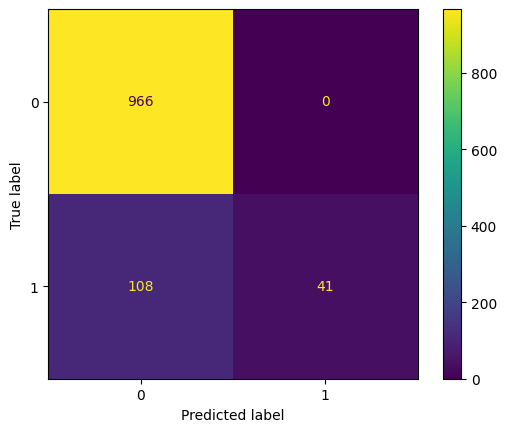

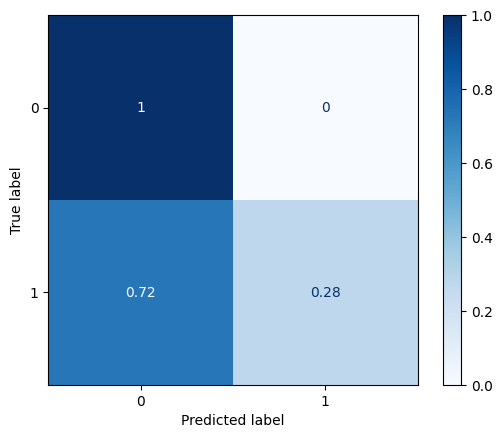

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Matriz de confusão
visualizacao = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels = classifier.classes_)
visualizacao.plot();
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize = 'true', cmap = 'Blues')

## Exercício dataset Titanic

In [ ]:
# Importando o csv para um pandas dataframe
df = pd.read_csv("/content/titanic.csv")
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [ ]:
dummies = pd.get_dummies(df['Sex'])


In [ ]:
dummies.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [ ]:
df_novo = pd.concat([df, dummies], axis = 'columns')

In [ ]:
df_novo.drop(['PassengerId','Name','Sex','female','Ticket','Cabin'], axis = 'columns', inplace = True)

In [ ]:
df_novo['Embarked'] = df_novo['Embarked'].fillna('S')

In [ ]:
df_novo['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df_novo['Embarked'] = le.fit_transform(df_novo['Embarked'])

In [ ]:
df_novo.isnull().any()

,0
Pclass,False
Age,True
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
male,False


In [ ]:
df_novo['Age']= df_novo['Age'].fillna(df_novo['Age'].mean())

In [ ]:
df_novo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Age       891 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    int64  
 6   Survived  891 non-null    int64  
 7   male      891 non-null    bool   
dtypes: bool(1), float64(2), int64(5)
memory usage: 49.7 KB


In [ ]:
df_novo.isnull().any()

,0
Pclass,False
Age,False
SibSp,False
Parch,False
Fare,False
Embarked,False
Survived,False
male,False


In [ ]:
df_novo.head()

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,male
0,3,22.0,1,0,7.2500,2,0,True
1,1,38.0,1,0,71.2833,0,1,False
2,3,26.0,0,0,7.9250,2,1,False
3,1,35.0,1,0,53.1000,2,1,False
4,3,35.0,0,0,8.0500,2,0,True


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X = df_novo.drop(['Survived'], axis = 1)
y = df_novo['Survived']

X_norm = sc.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size = 0.2, random_state = 42)

In [ ]:
knn_titanic = KNeighborsClassifier()

In [ ]:
knn_titanic.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
pred_knn_titanic = knn_titanic.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score
f1_score_knn_titanic = f1_score(y_test, pred_knn_titanic)
print(f1_score_knn_titanic)

0.7464788732394366


In [ ]:
print(classification_report(y_test, pred_knn_titanic))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Exercício dataset Wine ( direto do sklearn )

$ from sklearn import datasets

$ wine = datasets.load_wine()

In [ ]:
from sklearn import datasets
wine = datasets.load_wine(as_frame=True)

## Exercício dos Digitos

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [ ]:
df = pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
df['target'] = digits.target
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
df.shape

(1797, 65)

In [ ]:
arr = df.iloc[277, :-1].values

In [ ]:
arr

array([ 0.,  0.,  0.,  4., 13., 13.,  0.,  0.,  0.,  0.,  0., 10., 16.,
       16.,  1.,  0.,  0.,  0.,  3., 14., 16., 13.,  0.,  0.,  0.,  0.,
        8., 16., 16.,  5.,  0.,  0.,  0.,  3., 15., 16., 16.,  4.,  0.,
        0.,  0.,  4., 16., 16., 16.,  6.,  0.,  0.,  0.,  2.,  8., 15.,
       16.,  9.,  0.,  0.,  0.,  0.,  0.,  4., 14., 12.,  0.,  0.])

In [ ]:
from matplotlib import pyplot as plt


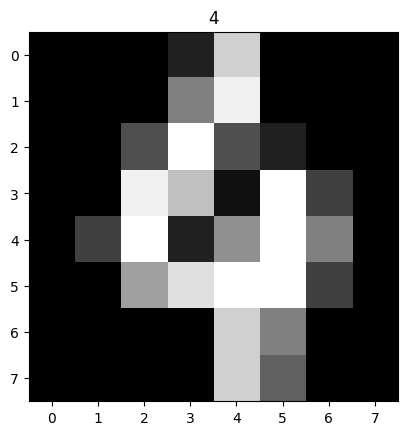

In [ ]:
num=100
arr = df.iloc[num, :-1].values
plt.imshow(arr.reshape(8,8), cmap = 'gray')
plt.title(str(df.iloc[num,-1]))
plt.show()

## K-Means

## $Não$ Supervisionado

Vamos agora entender como o algoritmo de Clusterização/Agrupamento funciona

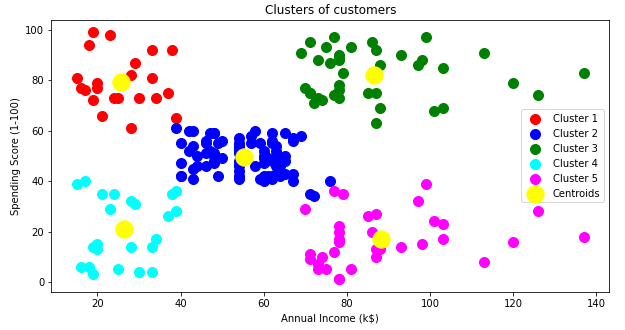

Banco de dados:
- Mall_Customers.csv
- Cluster data files 2D
- data.csv

### Exercícios

In [ ]:

# Vamos ler os data files, criar uma função para isso
def read_file(filename):
    lista = list()
    with open(filename, 'r') as info:
        for data in info:
            data = data.strip()
            data = data.split()
            lista.append([float(x) for x in data])
    return lista

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array(read_file('/content/3clusters_2D_573p.dat'))

In [ ]:
X

array([[15.55, 28.65],
       [14.9 , 27.55],
       [14.45, 28.35],
       ...,
       [35.25, 26.  ],
       [35.7 , 26.15],
       [34.4 , 25.6 ]])

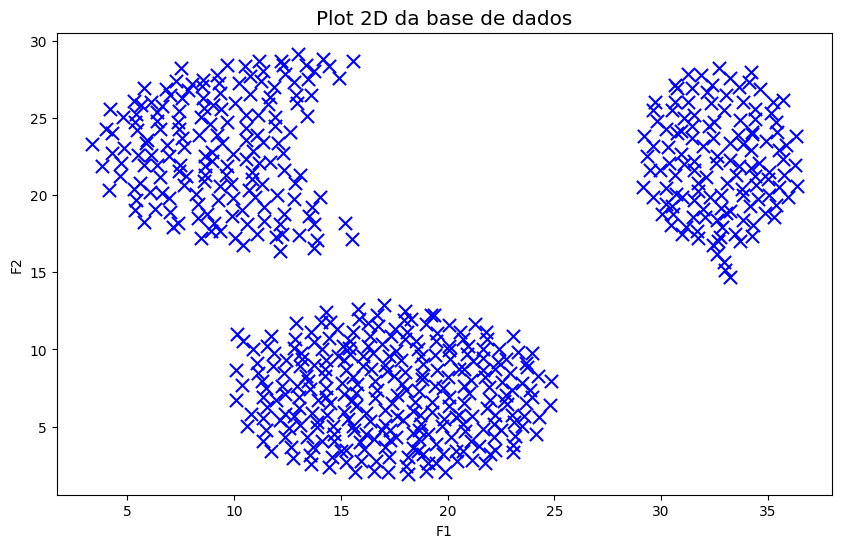

In [ ]:
# função para plotar os dados
def visualizarDados(X,Y):
    """
    Função usada para plotar os dados

    PLOTARDADOS(X,Y) plota os dados e seta os rotulos x e y da
    figura.
    """

    # definindo o tamanho da figura
    plt.figure(figsize=(10,6))

    # plota os dados
    plt.scatter( X, Y, marker='x', label = 'Dados', color='blue', s=90)

    # define os nomes do eixo x e do eixo y
    plt.xlabel(r'F1',fontsize='medium')
    plt.ylabel(r'F2',fontsize='medium')

    #define o título do gráfico
    plt.title('Plot 2D da base de dados', fontsize='x-large')


# chamando a função que plota os dados
visualizarDados(X[:,0],X[:,1])
plt.show()

In [ ]:
def findClosestCentroids(X, centroids):
    """
    Calcula o centróide mais próximo de cada um dos exemplos

    Parâmetros:
    -----------
    X: é uma matriz, onde cada linha representa um exemplo do problema avaliado

    centroids: é uma matriz, onde cada linha representa um centróide

    Saída:
    idx: um vetor que contém o índice do centróide mais próximo de cada objeto
    """

    n = X.shape[0] # quantidade de amostras

    # inicializa o valor de K
    K = centroids.shape[0];

    # Inicialização dos índices de cada linha
    idx = np.zeros( X.shape[0], dtype=int )

    for i in range(n):

        idx[i] = np.argmin(np.sqrt(np.sum((X[i]-centroids)**2,axis=1)))

    return idx

In [ ]:
# define uma quantidade de centróides
K = 3

# criar os k centróides iniciais
initial_centroids = np.array( [[20,20],[30,25],[25,15]] )

idx = findClosestCentroids(X, initial_centroids)

In [ ]:
def calculateCentroids(X, idx, K):
    """
    Retorna os novos centróides calculando a média das amostras de cada
    centróide atual.

    Esta função deve retornar uma matriz de centroides, onde cada linha
    representa um centróide.

    Parâmetros:
      X   - é a base de dados, onde cada linha representa uma amostra.
      idx - é um vetor onde cada elemento possui valor entre [0..K]. O elemento
            de índice i representa o índice do centróide mais próximo a i.
    """

    # varíaveis úteis
    m, n = X.shape # quantidade de amostras e número de atributos

    # você precisa retornar a seguinte variável corretamente
    centroides = np.zeros( [K, n] )

    for i in np.unique(idx):

        centroides[i] = np.mean(X[np.where(idx == i)],axis=0)

    ##########################################################################

    return centroides

In [ ]:
# chama a função
centroides = calculateCentroids(X, idx, K)

print('Novos centróides calculados a partir dos K centróides iniciais')
print(centroides);

Novos centróides calculados a partir dos K centróides iniciais
[[10.10774648 20.32535211]
 [32.75805085 22.56313559]
 [18.92975207  7.16446281]]


In [ ]:
import random

K = 3 # quantidade de centróides

max_iters = 4 # máximo de iterações que serão executadas

# Para facilitar, vamos criar manualmente os centróides
# iniciais. Porém, na prática, os centróides iniciais devem ser
# gerados automaticamente. Uma das formas de fazer isso é
# escolhendo aleatoriamente K amostras para serem os
# K centróides iniciais.
# initial_centroids = np.array( [[20,20],[30,25],[25,15]] )

# initial_centroids = np.array( [[30,10],[30,11],[30,12]] )

# Iniciando de forma randomica, levando em consideração o valor máximo de X
initial_centroids = np.array( [[random.random()*36,random.random()*36],
                               [random.random()*36,random.random()*36],
                               [random.random()*36,random.random()*36]] )

In [ ]:
def executa_kmedias(X, initial_centroids, max_iters, saveHistory = False):
    '''
    Roda o método K-médias sobre a base de dados X, onde cada linha de X
    é uma amostra.

    Esta função deve retornar os centróides encontrados na última iteração.
    Ela deve retornar também o vetor idx, onde cada elemento possui valor
    entre [0..K]. O elemento de índice i representa o índice do centróide
    mais próximo do dado i.

    Parâmetros:
       X                 - é a base de dados, onde cada linha representa uma amostra.
       initial_centroids - é uma matriz de centróides, onde cada linha representa
                           um centróide.
       max_iters         - é o máximo de iterações para o método
    '''

    #  inicializa alguns parâmetros

    m, n = X.shape # m é o número de amostras, n é o número de atributos

    # inicializa K com o número de centróides que é igual ao
    # ao número de linhas da matriz initial_centroids
    K = initial_centroids.shape[0]

    centroids = initial_centroids # inicializa a matriz de centroides
    previous_centroids = centroids  # inicializa a matriz que vai guardar os centroides

    # inicializa o vetor que irá guardar o índice do centróide mais próximo de cada amostra.
    idx = np.zeros( m )

    if saveHistory:
        # inicializa uma variável do tipo lista que irá guardar a matriz de centróides
        # e o vetor de índices dos centróides mais próximos obtidos em cada interação
        history = []

    #  executa o K-médias
    for i in range(max_iters):

        # imprime o número da iteração atual
        print('K-Médias - Iteração %d/%d' %(i, max_iters));

        # para cada amostra de X, encontra o centróide mais próximo
        idx = findClosestCentroids(X, centroids)

        if saveHistory:
            # salva o histórico
            history.append({'centroids': centroids, 'idx': idx})

        # dada a lista de centróides mais próximos de cada amostra
        # calcula o novo centroide.
        centroids = calculateCentroids(X, idx, K);

    if saveHistory:
        return centroids, idx, history
    else:
        return centroids, idx

In [ ]:
centroids, idx, history = executa_kmedias(X, initial_centroids, max_iters, saveHistory = True)
print('\nK-médias finalizado.\n')

K-Médias - Iteração 0/4
K-Médias - Iteração 1/4
K-Médias - Iteração 2/4
K-Médias - Iteração 3/4

K-médias finalizado.



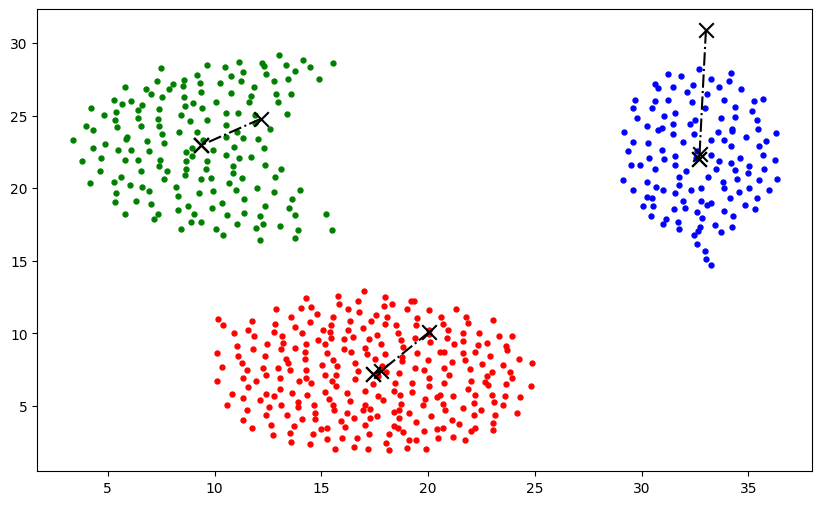

In [ ]:
# cria a função para plotar os dados
def visualizarDados_centroids(X, centroids, idx, history):

    # define o tamanho da figura
    plt.figure(figsize=(10,6))

    lcolors = ['b', 'g', 'r', 'c', 'm', 'y', 'w']

    for i in range( centroids.shape[0] ):

        # plota os dados
        plt.scatter( X[idx==i,0], X[idx==i,1], marker='.', label = 'Dados', color=lcolors[i], s=50)

    for j in range( len(history) ):

        for i in range( centroids.shape[0] ):
            # plota os dados
            plt.scatter( history[j]['centroids'][i,0], history[j]['centroids'][i,1], marker='x', color='black', s=110)

            if j>0:
                plt.plot( [history[j-1]['centroids'][i,0], history[j]['centroids'][i,0]], [history[j-1]['centroids'][i,1], history[j]['centroids'][i,1]], color='k', linestyle='-.')

    plt.show()

# chama a função que plota os dados
visualizarDados_centroids(X, initial_centroids, idx, history)

In [ ]:
class Kmeans_custom():

    # Função _init_
    def __init__(self, X, k):
      self.X = X
      self.k = k
      self.initial_centroids = np.random.random((self.k, self.X.shape[1])) * self.X.max()


    # Função achar centroides proximos
    def find_closest_centroids(self, centroides):
      n = X.shape[0] # quantidade de amostras


      # Inicialização dos índices de cada linha
      idx = np.zeros(n, dtype=int)

      for i in range(n):

          idx[i] = np.argmin(np.sqrt(np.sum((self.X[i]-centroides)**2,axis=1)))

      return idx



    # Função calcular centroides
    def calculate_centroids(self, idx, centroides):
        for i in np.unique(idx):

          centroides[i] = np.mean(X[np.where(idx == i)],axis=0)
        return centroides


    # Função fit (self, max_iters, save_history=True)
    def fit(self, max_iters, save_history=True):
       m, n = self.X.shape

       centroides = self.initial_centroids.copy()

       if save_history:
        history = []

        for i in range(max_iters):
          idx = self.find_closest_centroids(centroides)

          if save_history:
            history.append({'centroids': centroides, 'idx': idx})

          centroides = self.calculate_centroids(idx, centroides)

        self.class_centroides = centroides.copy()
        if save_history:
          return centroides, idx, history


    # Função de predict (self, x)
    def predict(self, x):
      idx = np.zeros(x.shape[0], dtype=int)
      for i in range(x.shape[0]):
        idx[i] = np.argmin(np.sqrt(np.sum((x[i]-self.class_centroides)**2,axis=1)))
      return idx, self.class_centroides

In [ ]:
kmeans = Kmeans_custom(X, 3)
kmeans.fit(max_iters=10)

(array([[0.37348142, 0.45675541, 0.52634316],
        [0.84940221, 0.70800017, 0.56884754],
        [0.33280609, 0.12326973, 0.12299217]]),
 array([1, 1, 1, ..., 1, 1, 1]),
 [{'centroids': array([[0.37348142, 0.45675541, 0.52634316],
          [0.84940221, 0.70800017, 0.56884754],
          [0.33280609, 0.12326973, 0.12299217]]),
   'idx': array([1, 1, 1, ..., 1, 1, 1])},
  {'centroids': array([[0.37348142, 0.45675541, 0.52634316],
          [0.84940221, 0.70800017, 0.56884754],
          [0.33280609, 0.12326973, 0.12299217]]),
   'idx': array([1, 1, 1, ..., 1, 1, 1])},
  {'centroids': array([[0.37348142, 0.45675541, 0.52634316],
          [0.84940221, 0.70800017, 0.56884754],
          [0.33280609, 0.12326973, 0.12299217]]),
   'idx': array([1, 1, 1, ..., 1, 1, 1])},
  {'centroids': array([[0.37348142, 0.45675541, 0.52634316],
          [0.84940221, 0.70800017, 0.56884754],
          [0.33280609, 0.12326973, 0.12299217]]),
   'idx': array([1, 1, 1, ..., 1, 1, 1])},
  {'centroids': arr

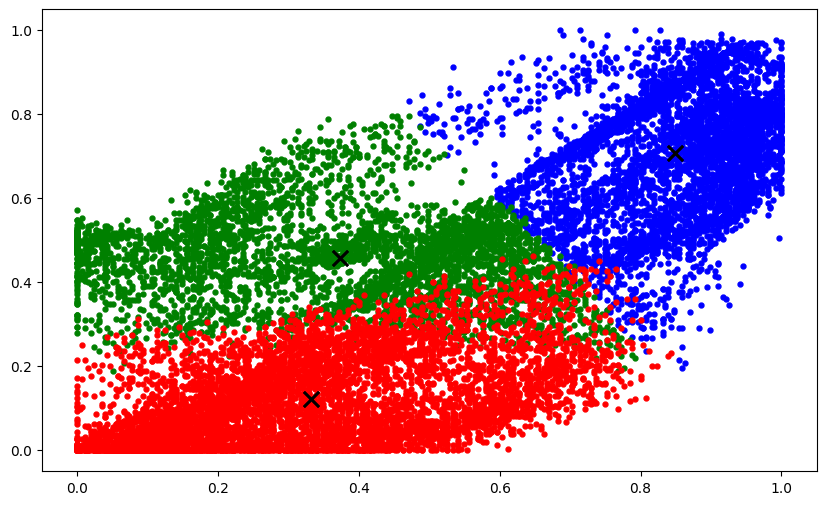

In [ ]:
kmeans = Kmeans_custom(X, 3)
centroids, idx, history = kmeans.fit(max_iters=10, save_history=True) # Call fit and store returned values

# chama a função que plota os dados
visualizar = visualizarDados_centroids(X, centroids, idx, history) # Pass the returned values to the plotting function

In [ ]:
# Realizando um predict
pred, classes = kmeans.predict(np.array([30,15]))
print(pred, classes)

[0 0] [[0.84947475 0.70798806 0.56877786]
 [0.37350861 0.4568306  0.5264375 ]
 [0.33280609 0.12326973 0.12299217]]


## Utilização e visualização do Mall Customers

In [ ]:
# Importando o dataset
dataset = pd.read_csv('/content/Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

In [ ]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Visualizando o método do cotovelo

In [ ]:
# Importando o Kmeans do Sklearn
from sklearn.cluster import KMeans

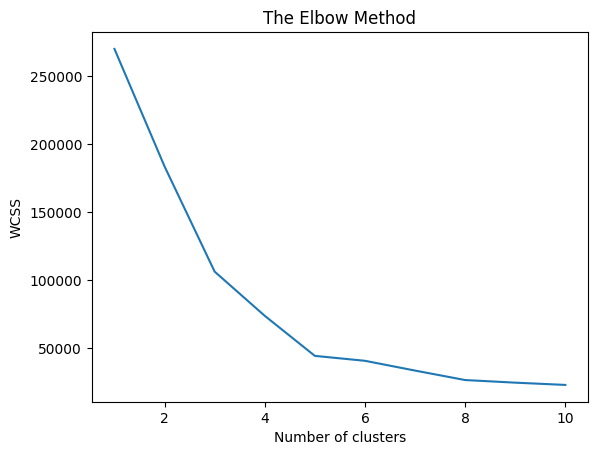

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 'auto', random_state = 42) # Changed 'n_int' to 'n_init'
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Treinando o modelo
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


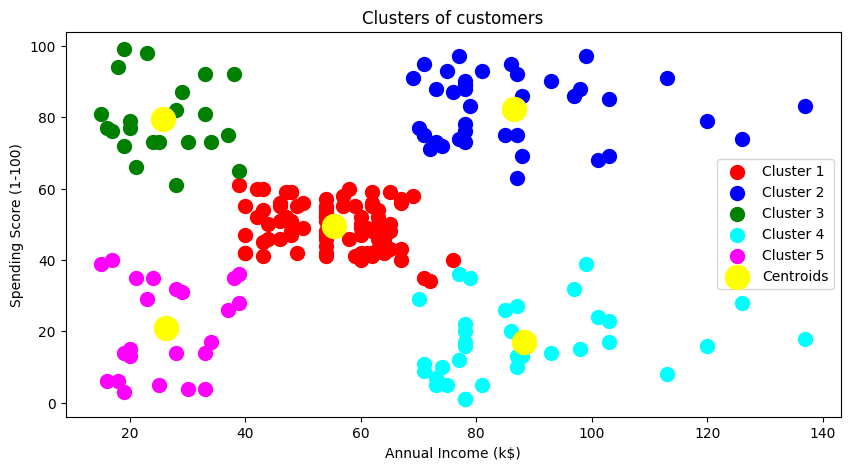

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Aplicar o Kmeans no data.csv

In [ ]:
# Importando o dataset
df_dataset = pd.read_csv( 'datasets/data.csv', sep=',')

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/data.csv'

In [ ]:
df_dataset.head()

In [ ]:
# pega os valores do dataframe
X = df_dataset.values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

In [ ]:
# chamando a função que plota os dados
visualizarDados(X[:,0],X[:,1])
plt.show()

In [ ]:
# Metodo do cotovelo
inercia = []
K_range = range(1, 11)  # Testar de 1 até 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(K_range, inercia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()


In [ ]:
# Treinando com o número de clusters encontrado
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
# Treinando o modelo


In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Utilizando o Kmeans para compressão de cores em imagens

In [ ]:
bolo = plt.imread('/content/image3.jpg')

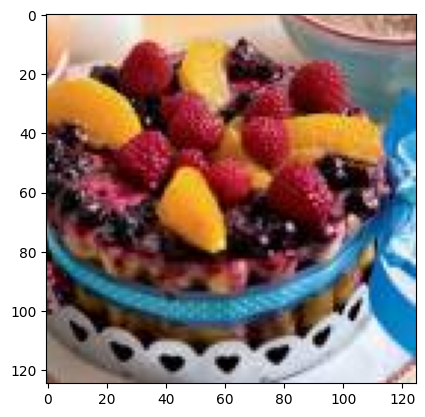

In [ ]:
plt.imshow(bolo)
plt.show()

In [ ]:
bolo.shape

(125, 125, 3)

In [ ]:
n_colors = 12

# Convertendo para o range[0-1]
bolo = bolo / 255

In [ ]:
bolo

array([[[0.98431373, 0.84705882, 0.76862745],
        [0.99215686, 0.85490196, 0.76862745],
        [1.        , 0.85882353, 0.77254902],
        ...,
        [0.75686275, 0.56862745, 0.49019608],
        [0.63921569, 0.45098039, 0.37254902],
        [0.7254902 , 0.5254902 , 0.45098039]],

       [[0.96862745, 0.82745098, 0.74117647],
        [0.97647059, 0.83529412, 0.74117647],
        [0.98823529, 0.84313725, 0.74117647],
        ...,
        [0.69019608, 0.50588235, 0.42745098],
        [0.59215686, 0.40784314, 0.32941176],
        [0.62352941, 0.43529412, 0.35686275]],

       [[0.94509804, 0.8       , 0.69411765],
        [0.95294118, 0.80784314, 0.70196078],
        [0.97254902, 0.81960784, 0.70588235],
        ...,
        [0.55294118, 0.37647059, 0.30196078],
        [0.56470588, 0.38823529, 0.31372549],
        [0.60784314, 0.42352941, 0.35294118]],

       ...,

       [[0.4       , 0.29411765, 0.25882353],
        [0.49803922, 0.40392157, 0.36470588],
        [0.55294118, 0

In [ ]:
w, h, d = tuple(bolo.shape)

In [ ]:
image_array = np.reshape(bolo, (w * h, d))

In [ ]:
image_array.shape

(15625, 3)

In [ ]:
X = image_array
print('\nNova dimensão: ',  image_array.shape)

print('\nValores dos 5 primeiros pixels:')
print(image_array[0:5,:])


Nova dimensão:  (15625, 3)

Valores dos 5 primeiros pixels:
[[0.98431373 0.84705882 0.76862745]
 [0.99215686 0.85490196 0.76862745]
 [1.         0.85882353 0.77254902]
 [0.99215686 0.85098039 0.75686275]
 [0.98039216 0.83529412 0.73333333]]


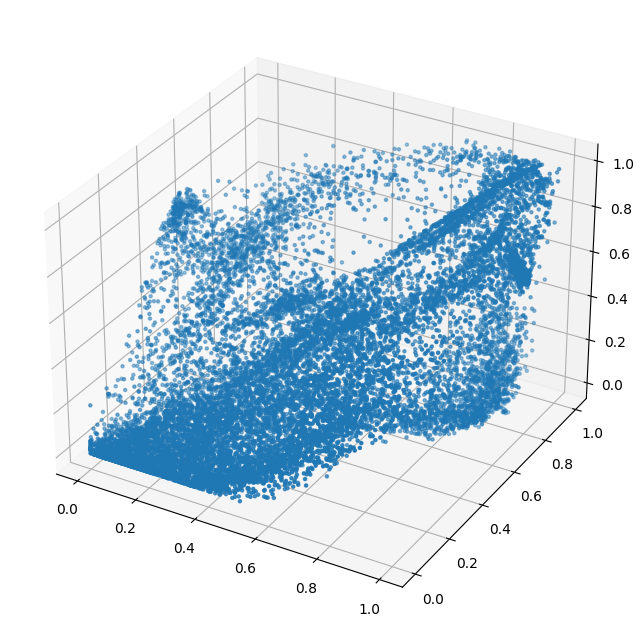

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(image_array[:,0], image_array[:,1], image_array[:,2], marker='.')

plt.show()

In [ ]:
k_new = Kmeans_custom(X, n_colors)

In [ ]:
_ = k_new.fit(30)

In [ ]:
inds, cents = k_new.predict(X)

In [ ]:
# Agora vamos mapear amostra da base de dados (pixel) por seu centróide mais próximo.
X_recuperado = cents [inds, :]

# Vamos restaurar as dimensões originais da matriz de pixels
X_recuperado = np.reshape(np.ravel(X_recuperado), (bolo.shape[0], bolo.shape[1], 3))

In [ ]:
# Load Image and transform to a 2D numpy array.
w, h, d = tuple(X_recuperado.shape)


In [ ]:
x_rec_array = np.reshape(X_recuperado, (w * h, d))

In [ ]:
x_rec_array.shape

(15625, 3)

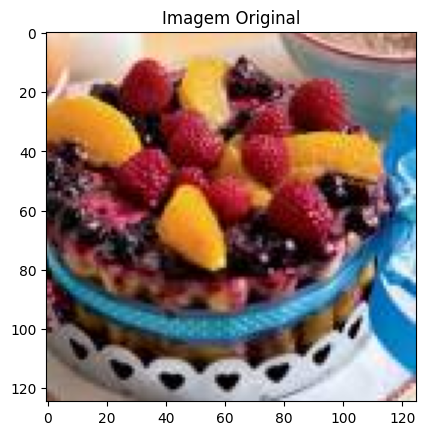

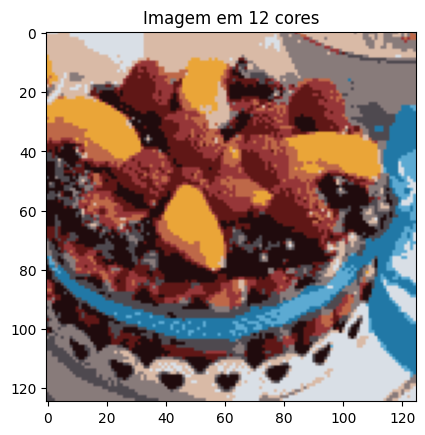

In [ ]:
# Vamos plotar a imagem original
plt.imshow(bolo)
plt.title('Imagem Original')
plt.show()

# Vamos plotar a imagem compactada
plt.imshow(X_recuperado)
plt.title('Imagem em {} cores'.format(n_colors))
plt.show()

In [ ]:
# Utilizando o Sklearn
SK = KMeans(n_clusters=n_colors, random_state=0)

In [ ]:
SK.fit(imagem_array)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=12, random_state=0)

In [ ]:
pred_SK = SK.predict(image_array)

In [ ]:
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [ ]:
x_rec = kmeans.cluster_centers_[labels, :]

In [ ]:
x_recovered = np.reshape(np.ravel(x_rec), (bolo.shape[0], bolo.shape[1], 3))

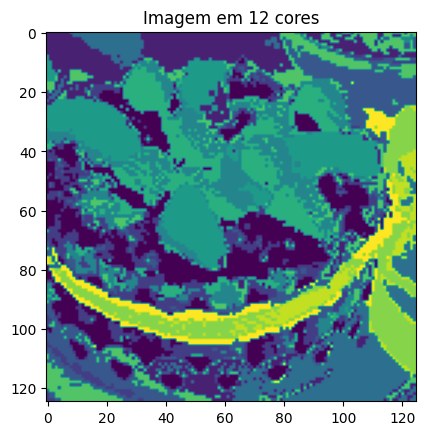

In [ ]:
# Reshape pred_SK back into a 2D image
# Assuming the original image was square, calculate the side length
side_length = int(np.sqrt(pred_SK.shape[0]))
pred_SK_image = pred_SK.reshape(side_length, side_length)

# Now you can display the clustered image
plt.imshow(pred_SK_image)
plt.title('Imagem em {} cores'.format(n_colors))
plt.show()

In [ ]:
# Vamos restaurar as dimensões originais da matriz de pixels


In [ ]:
# Vamos plotar a imagem original


# Vamos plotar a imagem compactada


In [ ]:
# Imagem do Cachorro
